In [184]:
import pandas as pd
from sklearn.datasets import make_circles

In [185]:
df = make_circles(n_samples=100,random_state=42 ,noise=5)
print(df)

(array([[ 2.75286411e+00, -5.20906568e+00],
       [ 3.12403413e+00,  6.81280598e+00],
       [ 4.10721466e-01,  3.45545143e+00],
       [-3.67265892e+00, -1.14772435e+00],
       [ 8.07367505e+00, -6.30403878e+00],
       [ 4.93740829e+00,  7.65029509e+00],
       [ 1.35964890e+00, -8.05331234e+00],
       [ 9.87012524e-01, -8.75822973e-01],
       [ 2.64799076e+00,  4.63166827e+00],
       [-2.89850940e+00, -4.21948180e+00],
       [-1.39009328e+00, -4.05727512e+00],
       [-5.65716038e-02, -1.15489151e+00],
       [ 1.23927746e+01, -4.92650253e+00],
       [-4.44606593e+00,  1.27538742e+00],
       [ 4.61073909e+00,  1.06752847e+01],
       [ 8.99090918e+00,  4.60041906e+00],
       [ 6.71604467e-01,  4.38288533e+00],
       [-3.82647662e+00, -1.77978139e+00],
       [-7.34933071e+00, -1.46210853e-01],
       [ 4.08423782e+00, -1.73300929e+00],
       [-3.22300106e+00, -1.32866252e+00],
       [ 3.67064867e+00, -2.07724457e+00],
       [ 3.25749132e+00, -6.68195436e+00],
       [-3

In [186]:
X = df[0]
X.shape

(100, 2)

In [187]:
y = df[1]
y.shape

(100,)

In [188]:
import numpy as np

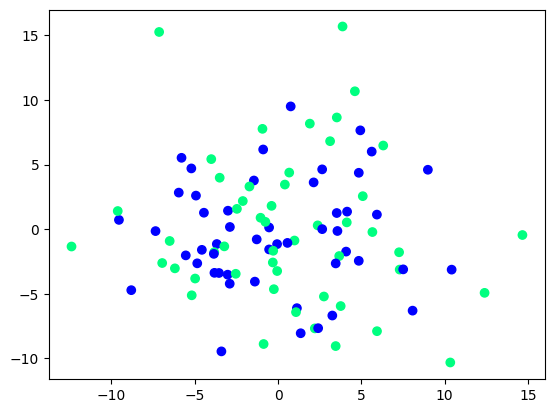

In [189]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.show()

In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score , RandomizedSearchCV

In [191]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [192]:
params = {
    'n_estimators' : [10,20,50],
    'max_features' : ['auto','sqrt'],
    'min_samples_leaf' : [1,2],
    'min_samples_split' : [2,5],
}

In [193]:
clf = RandomForestClassifier(n_estimators=5)

In [194]:
clf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=5)

In [195]:
y_pred = clf.predict(X_test)

In [196]:
from sklearn.metrics import accuracy_score

print('accuracy is :',accuracy_score(y_test,y_pred))

accuracy is : 0.35


In [197]:
clf2 = GridSearchCV(clf,param_grid=params,cv=5,n_jobs=1)

In [198]:
clf2.fit(X_train,y_train)
y_pred = clf.predict(X_test)

print('accuracy is :',accuracy_score(y_test,y_pred))

accuracy is : 0.35


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

In [199]:
print(clf2.best_params_)
print(clf2.best_score_)

{'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
0.5125


In [200]:
clf3 = RandomizedSearchCV(clf,param_distributions=params,cv=5,n_jobs=1)

In [201]:
clf3.fit(X_train,y_train)
y_pred = clf.predict(X_test)

print('accuracy is :',accuracy_score(y_test,y_pred))

accuracy is : 0.35


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

In [202]:
from sklearn.datasets import load_iris

In [203]:
data = load_iris(as_frame=True)

In [204]:
X = data.data
y = data.target

In [205]:
df = pd.merge(X,y,left_index=True,right_index=True)

In [206]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [207]:
df = df.drop(columns=['petal length (cm)','petal width (cm)'],axis=1)

In [208]:
from sklearn.ensemble import BaggingClassifier

In [209]:
X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,:2],df.iloc[:,-1],test_size=0.2,random_state=42)

In [210]:
from sklearn.svm import SVC

In [211]:
Smodel = SVC()

In [212]:
Bmodel = BaggingClassifier(n_estimators=15,estimator=Smodel)

In [213]:
Bmodel.fit(X_train,y_train)

BaggingClassifier(estimator=SVC(), n_estimators=15)

In [214]:
y_pred = Bmodel.predict(X_test)

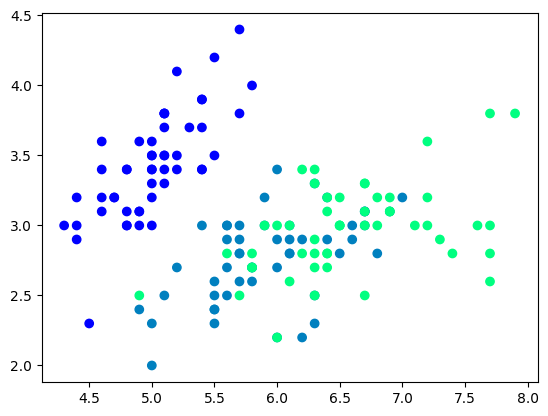

In [215]:
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y, cmap='winter')

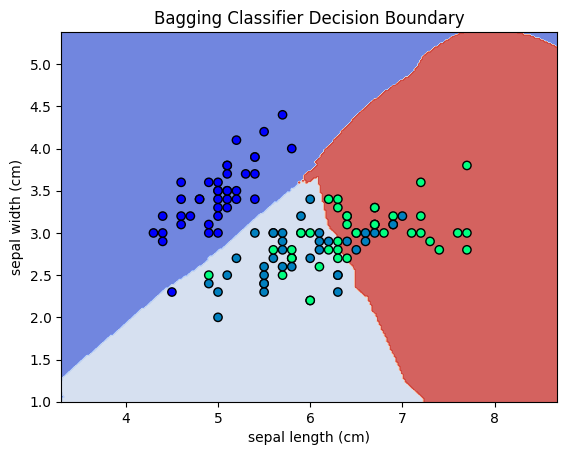

In [216]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Convert meshgrid data to DataFrame with column names to match X_train
    Z = model.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns))
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='winter', edgecolor='k')
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title("Bagging Classifier Decision Boundary")
    plt.show()

plot_decision_boundary(Bmodel, X_train, y_train)

In [217]:
accuracy_score(y_test,y_pred)

0.9

In [218]:
from sklearn.ensemble import AdaBoostClassifier

In [219]:
ada = AdaBoostClassifier(n_estimators=10)

In [220]:
ada.fit(X_train,y_train)
print(accuracy_score(y_test,ada.predict(X_test)))

0.8


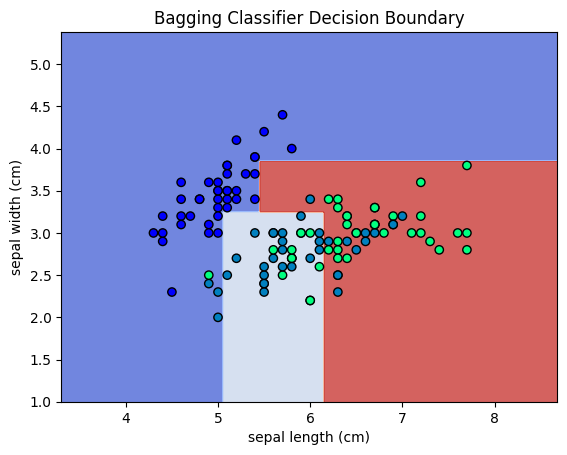

In [221]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Convert meshgrid data to DataFrame with column names to match X_train
    Z = model.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns))
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='winter', edgecolor='k')
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title("Bagging Classifier Decision Boundary")
    plt.show()

plot_decision_boundary(ada, X_train, y_train)

In [222]:
from sklearn.ensemble import GradientBoostingClassifier

In [249]:
gbmodel = GradientBoostingClassifier(n_estimators=250,learning_rate=0.05)

In [250]:
gbmodel.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=250)

0.8333333333333334


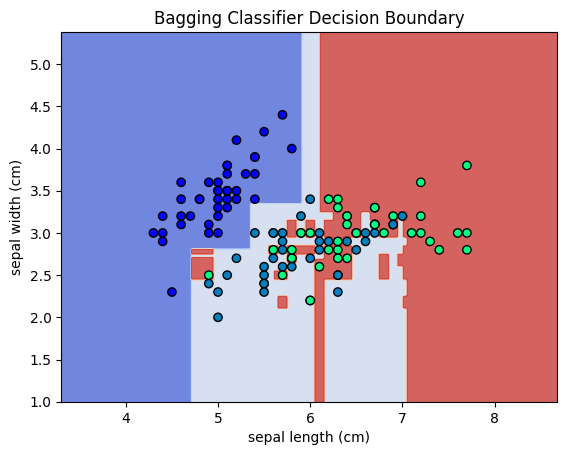

In [251]:
y_pred = gbmodel.predict(X_test)
print(accuracy_score(y_test,y_pred))
plot_decision_boundary(gbmodel,X_train,y_train)

In [ ]:
# from matplotlib.colors import ListedColormap

# custom_cmap = ListedColormap(["black", "yellow"])
# rng = np.random.default_rng()

# grid_size = (10, 10)
# grid = rng.choice([0, 1], size=grid_size)

# plt.figure(figsize=(6, 6))
# plt.imshow(grid, cmap=custom_cmap)
# plt.show()

In [253]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [258]:
class BaggingClassifier:
    def __init__(self, base_classifier, n_estimators):
        self.base_classifier = base_classifier
        self.n_estimators = n_estimators
        self.classifiers = []

    def fit(self, X, y):
      for _ in range(self.n_estimators):
        indices = np.random.choice(len(X), len(X), replace=True)
        X_sampled, y_sampled = X[indices], y[indices]
        clf = self.base_classifier.__class__()
        clf.fit(X_sampled, y_sampled)
        self.classifiers.append(clf)
      return self.classifiers

    def predict(self, X):
      predictions = np.array([clf.predict(X) for clf in self.classifiers])
      majority_votes = np.apply_along_axis(
      lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
      return majority_votes

In [259]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [260]:
base_clf = DecisionTreeClassifier()
model = BaggingClassifier(base_classifier=base_clf, n_estimators=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9472222222222222


In [261]:
for i, clf in enumerate(model.classifiers):
    y_pred_i = clf.predict(X_test)
    acc_i = accuracy_score(y_test, y_pred_i)
    print(f"Accuracy of classifier {i+1}: {acc_i:.4f}")

Accuracy of classifier 1: 0.8417
Accuracy of classifier 2: 0.8528
Accuracy of classifier 3: 0.8361
Accuracy of classifier 4: 0.8278
Accuracy of classifier 5: 0.8139
Accuracy of classifier 6: 0.8750
Accuracy of classifier 7: 0.8111
Accuracy of classifier 8: 0.8333
Accuracy of classifier 9: 0.8417
Accuracy of classifier 10: 0.8167
